# Color-Magnitude Diagram of the 47 Tuc Globlular Cluster

**Learning objective:** Make a color-magnitude diagram of the "47 Tuc Globular Cluster" from the the LSSTComCam data in the 47 Tuc field.

**LSST data products:** `deepCoadd`, `Visit`, `Object`, `CcdVisit`

**Packages:** `lsst.rsp`, `lsst.daf.butler`

**Credit:** 
Michael Solontoi, based on the 301.1 tutorial Originally developed by the Rubin Community Science team. Please consider acknowledging them if this notebook is used for the preparation of journal articles, software releases, or other notebooks.

**Get Support:**
Everyone is encouraged to ask questions or raise issues in the 
<a href="https://community.lsst.org/c/support">Support Category</a> 
of the Rubin Community Forum.
Rubin staff will respond to all questions posted there.

## 1. Introduction

This notebook examines the DP1 data products in the "47 Tuc" field: assess sky coverage and depth, visit distribution over time, image quality, and the distributions of stars and galaxies in color-magnitude and color-color diagrams (CMD and CCD). 

47 Tucanae ("47 Tuc") is a bright, dense star cluster in the constellation Tucanae, located about 4.45 kpc (14,500 ly) away from Earth, and is visible to the naked eye with an apparent magnitude of about 4, containing over 10,000 stars. 

The ComCam field targeting this cluster is centered at (RA, Dec) = (6.128, –72.090) degrees. It is representative of the crowded fields that LSST will encounter in the Milky Way. 47 Tuc overlaps with the Small Magellanic Cloud (SMC) on the sky, but these are distinct objects: 47 Tuc is a globular cluster of the Milky Way's halo, while the SMC is a dwarf satellite galaxy orbiting around the Milky Way. 

The figure below, adapted from [Nidever et al. 2021](https://ui.adsabs.harvard.edu/abs/2021AJ....161...74N/abstract), is based on DECam images acquired through the Survey of the MAgellanic Stellar History (SMASH) program, depicting the sky positions of 47 Tuc and the SMC.

<div>
    <center>
    <figure>
    <img src="./47tuc_SMC.jpg" width="500"/>
    </figure>
    </center>
</div>

**Related tutorials:** The 100-level tutorials demonstrate how to use the butler, the TAP service, and the Firefly image display. The 200-level tutorials introduce the types of image and catalog data. The DP1 301.1 tutorial is the basis of this exploration, and contains additional explorations of the DP1 47 Tuc field beyond this example of making a color-magnitude diagram.


### 1.1. Import packages

Import `numpy`, a fundamental package for scientific computing with arrays in Python (<a href="https://numpy.org">numpy.org</a>), and `matplotlib`, a comprehensive library for data visualization (<a href="https://matplotlib.org/">matplotlib.org</a>; <a href="https://matplotlib.org/stable/gallery/index.html">matplotlib gallery</a>), including custom shapes (`Polygon`) and lines (`mlines`). `itertools` supports efficient iteration and combinatorics.

From the `lsst` package, import modules for accessing the Table Access Protocol (TAP) service, for retrieving datasets from the butler, and for image displaying from the LSST Science Pipelines (<a href="https://pipelines.lsst.io/">pipelines.lsst.io</a>). Additional modules support spherical geometry (`sphgeom`), and standardized multiband plotting (`lsst.utils.plotting`) for LSST data analysis and visualization.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import matplotlib.lines as mlines
import itertools

from lsst.rsp import get_tap_service
from lsst.daf.butler import Butler
#import lsst.afw.display as afw_display
import lsst.sphgeom as sphgeom
from lsst.utils.plotting import (
    get_multiband_plot_colors,
    get_multiband_plot_symbols,
    get_multiband_plot_linestyles,
)

### 1.2. Define parameters and functions

Create an instance of the TAP service, and assert that it exists.

In [2]:
service = get_tap_service("tap")
assert service is not None

Create an instance of the butler, and assert that it exists.

In [3]:
butler = Butler('dp1', collections="LSSTComCam/DP1")
assert butler is not None

Define the approximate central coordinates of the 47 Tuc field, and the `region` within 1 degree of this center.

In [4]:
ra_cen = 6.128
dec_cen = -72.090
radius = 1.0

region = sphgeom.Region.from_ivoa_pos(f"CIRCLE {ra_cen} {dec_cen} {radius}")

Define parameters to use colorblind-friendly colors with `matplotlib`.

In [5]:
plt.style.use('seaborn-v0_8-colorblind')
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

Define colors, symbols, and linestyles to represent the six LSST filters, $ugrizy$.

In [6]:
filter_colors = get_multiband_plot_colors()
filter_symbols = get_multiband_plot_symbols()
filter_linestyles = get_multiband_plot_linestyles()

We'll be looking at the four filters *g*, *r*, *i*, and *y* so we'll define an array of those labels to use.

In [7]:
field_filters = ['g', 'r', 'i', 'y']

## 2. Object (detections)

The `Object` table contains forced measurements on the deep coadded images at the locations of all objects detected with signal-to-noise ratio > 5 in a `deep_coadd` of any filter.

Query the `Object` table for objects in the field, and return their coordinates, the value of E(B-V) at their location, and their PSF and `cModel` AB magnitudes.

In [8]:
query = """SELECT objectId, coord_ra, coord_dec, ebv,
        {}_psfMag, {}_cModelMag, {}_psfMag, {}_cModelMag,
        {}_psfMag, {}_cModelMag, {}_psfMag, {}_cModelMag,
        refExtendedness
        FROM dp1.Object
        WHERE CONTAINS(POINT('ICRS', coord_ra, coord_dec),
              CIRCLE('ICRS', {}, {}, {})) = 1
        """.format(field_filters[0], field_filters[0],
                   field_filters[1], field_filters[1],
                   field_filters[2], field_filters[2],
                   field_filters[3], field_filters[3],
                   ra_cen, dec_cen, radius)

In [9]:
job = service.submit_job(query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
if job.phase == 'ERROR':
    job.raise_if_error()

Job phase is COMPLETED


In [10]:
assert job.phase == 'COMPLETED'
objtab = job.fetch_result().to_table()

## 2.1 Stars vs Galaxies

Use the `refExtendedness` flag to distinguish them: treat objects with `refExtendedness == 1` as likely galaxies (extended) and those with `refExtendedness == 0` as likely stars (point sources).

Use `cModelMag` mags for galaxies and `psfMag` for stars.

In [11]:
ptsource = (objtab['refExtendedness'] == 0)

# 3. Analysis

A short demonstration of making Color-Magnitude Diagrams (CMD) and Color-Color Diagrams (CCD).


## 3.1 Color-Magnitude Diagrams

Here we make a plot of the $(g-r)$ color index vs the $r$ magnitude. Since we are interested in stars, we will restrict our plotting to just the objects we identified early as point sources by taking only `objtab[ptsource]`. Since there are *a lot* of stars in our plot we'll set the alpha (transparency) of each dot to be low.

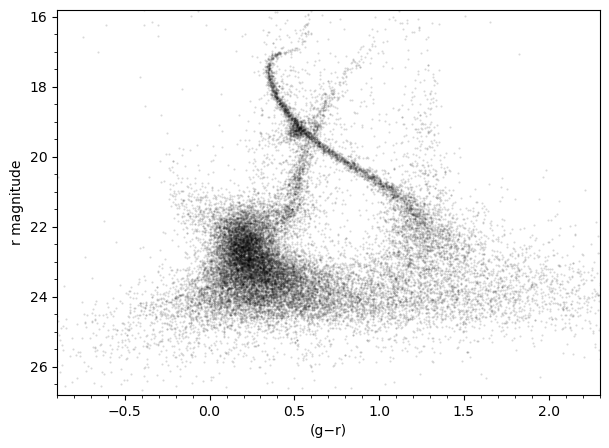

In [31]:
fig, ax = plt.subplots(figsize=(7,5))

grmin, grmax = -0.9, 2.3

ax.plot(objtab[ptsource]['g_psfMag']-objtab[ptsource]['r_psfMag'],
           objtab[ptsource]['r_psfMag'], alpha=0.15, marker='.', linestyle='None',markersize=1, color='k')
ax.set_xlim(grmin, grmax)
ax.set_ylim(magmax, magmin)
ax.set_xlabel(r'(g−r)')
ax.set_ylabel(r'r magnitude')
ax.minorticks_on()

As seen in several other RSP tutorials there are a number of ways to try and plot these rather dense plots. Here is another example using the `hexbin()` plotting function:

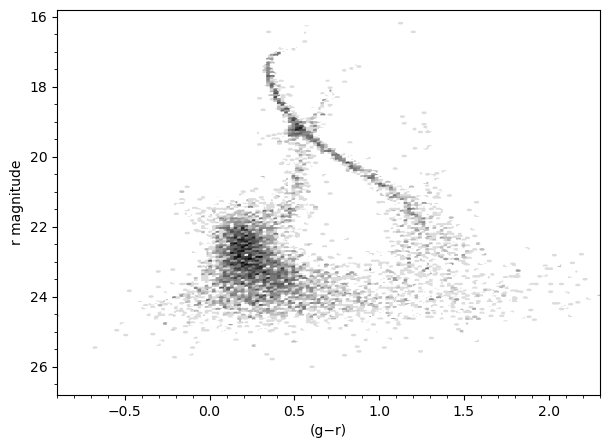

In [32]:
fig, ax = plt.subplots(figsize=(7,5))

grmin, grmax = -0.9, 2.3

ax.hexbin(objtab[ptsource]['g_psfMag']-objtab[ptsource]['r_psfMag'],
           objtab[ptsource]['r_psfMag'], gridsize=(150, 200),
           extent=(grmin, grmax, magmin, magmax), bins='log', cmap='Grays')
ax.set_xlim(grmin, grmax)
ax.set_ylim(magmax, magmin)
ax.set_xlabel(r'(g−r)')
ax.set_ylabel(r'r magnitude')
ax.minorticks_on()

Looking at the plot one can see that there is quite a bit of "contamination" - stars in the CMD that are *not* part of 47 Tuc. The Globular cluster 47 Tuc lies more than 2 degrees from the main body of the Small Magellanic Cloud (SMC), but a diffuse stellar population from the SMC extends into the 47 Tuc field, contributing to the CMD. 

For example, the "blob" of stars in the lower left are not part of 47 Tuc and are likely stellar populations in the outer SMC outlines in a red box below:

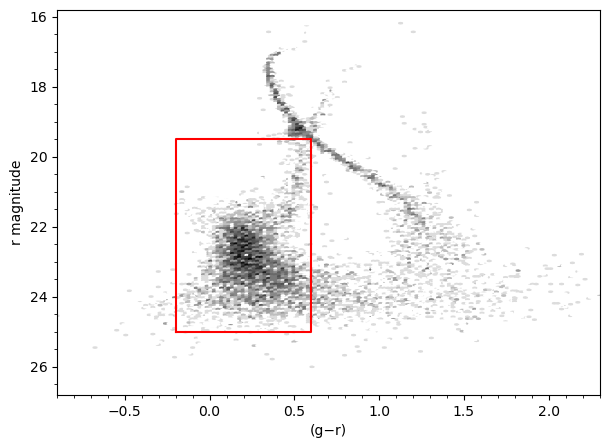

In [33]:
fig, ax = plt.subplots(figsize=(7,5))

grmin, grmax = -0.9, 2.3

ax.hexbin(objtab[ptsource]['g_psfMag']-objtab[ptsource]['r_psfMag'],
           objtab[ptsource]['r_psfMag'], gridsize=(150, 200),
           extent=(grmin, grmax, magmin, magmax), bins='log', cmap='Grays')
ax.plot([-0.2, -0.2, 0.6, 0.6, -0.2], [25, 19.5, 19.5, 25, 25], color='Red')
ax.set_xlim(grmin, grmax)
ax.set_ylim(magmax, magmin)
ax.set_xlabel(r'(g−r)')
ax.set_ylabel(r'r magnitude')
ax.minorticks_on()

# 4. Extensions and Projects

Try to "clean-up" the CMD for 47 Tuc by removing the contaminating stars from the SMC to make a CMD of only the stars in 47 Tuc. There are a number of ways to try and do this, and several methods are described in: [Choi, et al., 2005](https://iopscience.iop.org/article/10.3847/1538-4357/adfb70) and 
